In [2]:
import tensorflow as tf
from tensorflow import keras

import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
(data_train, data_val, data_test), data_info = tfds.load('cats_vs_dogs', 
                                               split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'], 
                                               shuffle_files=True, 
                                               as_supervised=True, 
                                               with_info=True
                                               )

In [4]:
print("Traing set size: ", len(data_train))
print("Validation set size: ", len(data_val))
print("Test set size: ", len(data_test))

Traing set size:  16283
Validation set size:  3490
Test set size:  3489


In [5]:
cat_count = 0
dog_count = 0

for _, label in data_train:
    if label.numpy() == 0:
        cat_count += 1
    else:
        dog_count += 1

print("Cat count in training set: ", cat_count)
print("Dog count in training set: ", dog_count)

Cat count in training set:  8195
Dog count in training set:  8088


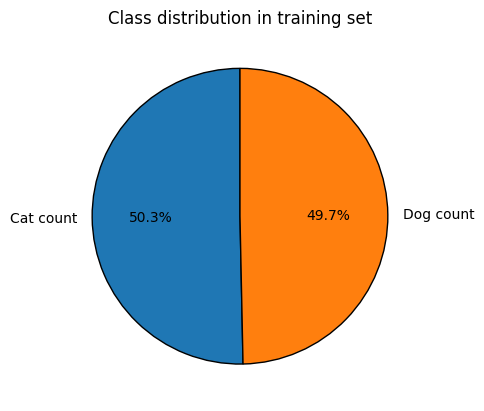

In [6]:
plt.pie([cat_count, dog_count], labels=["Cat count", "Dog count"], autopct= '%1.1f%%', startangle = 90, wedgeprops = {'edgecolor': 'black'})
plt.title("Class distribution in training set")
plt.show()

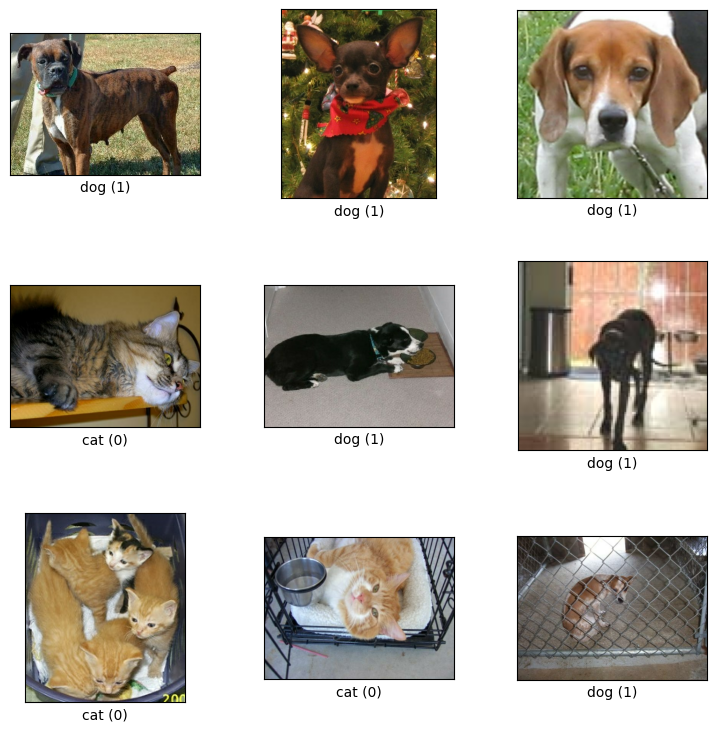

In [7]:
fig = tfds.show_examples(data_train, data_info)

In [8]:
cat_count = 0
dog_count = 0

for _, label in data_val:
    if label.numpy() == 0:
        cat_count += 1
    else:
        dog_count += 1

print("Cat count in val set: ", cat_count)
print("Dog count in val set: ", dog_count)

Cat count in val set:  1743
Dog count in val set:  1747


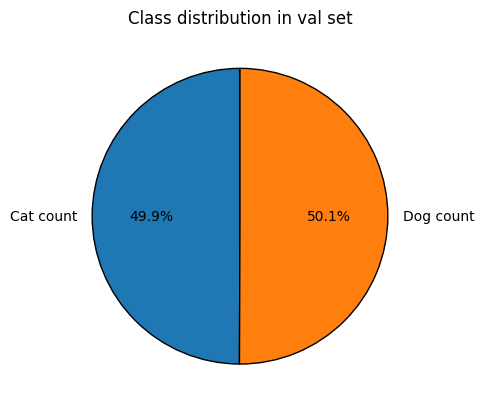

In [9]:
plt.pie([cat_count, dog_count], labels=["Cat count", "Dog count"], autopct= '%1.1f%%', startangle = 90, wedgeprops = {'edgecolor': 'black'})
plt.title("Class distribution in val set")
plt.show()

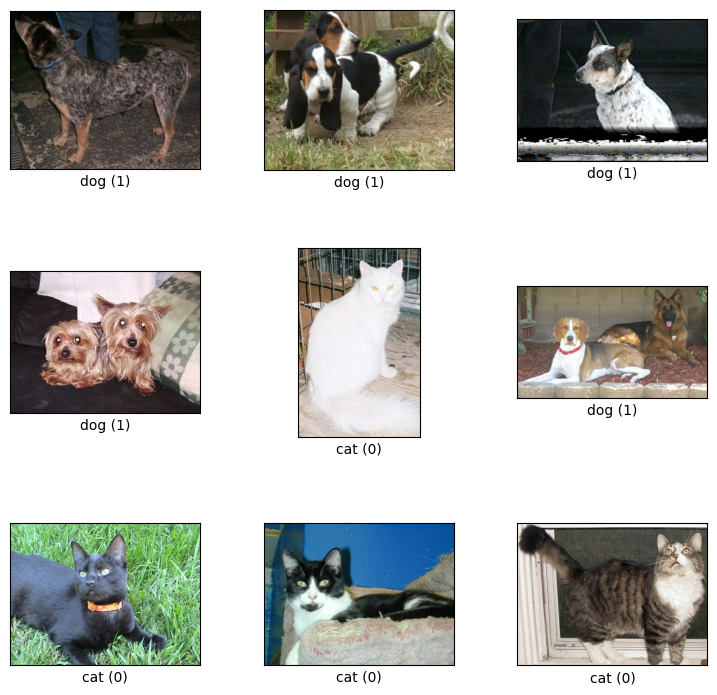

In [10]:
fig = tfds.show_examples(data_val, data_info)

In [11]:
cat_count = 0
dog_count = 0

for _, label in data_test:
    if label.numpy() == 0:
        cat_count += 1
    else:
        dog_count += 1

print("Cat count in test set: ", cat_count)
print("Dog count in test set: ", dog_count)

Cat count in test set:  1720
Dog count in test set:  1769


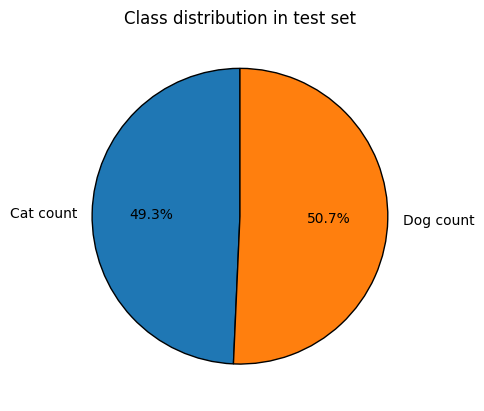

In [12]:
plt.pie([cat_count, dog_count], labels=["Cat count", "Dog count"], autopct= '%1.1f%%', startangle = 90, wedgeprops = {'edgecolor': 'black'})
plt.title("Class distribution in test set")
plt.show()

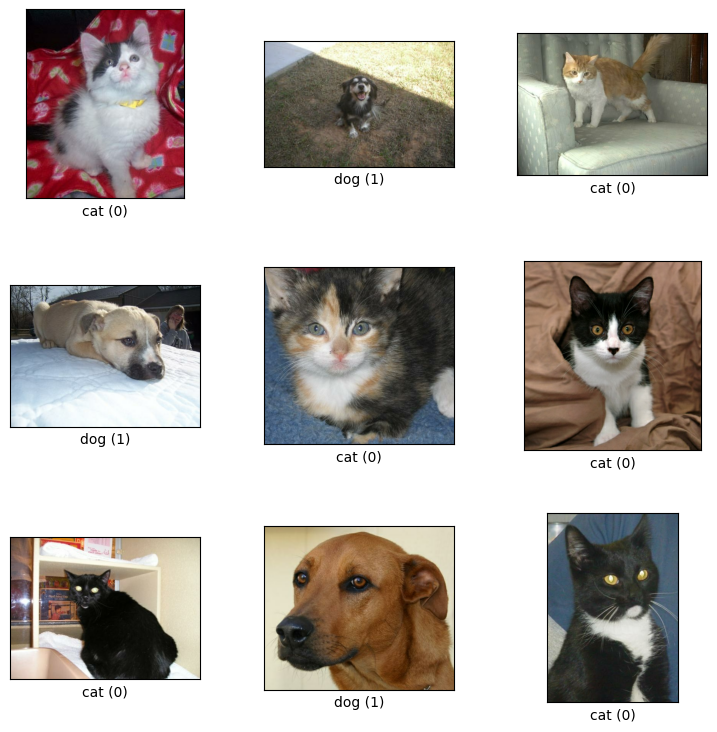

In [13]:
fig = tfds.show_examples(data_test, data_info)

In [17]:
def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255., label

In [18]:
# Training pipeline
data_train = data_train.map(normalize_img)
data_train = data_train.cache()
data_train = data_train.shuffle(data_info.splits["train[:70%]"].num_examples)
data_train = data_train.batch(128)

In [19]:
# Validation pipeline
data_val = data_val.map(normalize_img)
data_val = data_val.batch(128)
data_val = data_val.cache()

In [20]:
# Testing pipeline
data_test = data_test.map(normalize_img)
data_test = data_test.batch(128)
data_test = data_test.cache()